In [126]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn

In [127]:
df = pd.read_csv('X_train.csv')

In [128]:
y_train = pd.read_csv('y_train.csv')

In [129]:
# Séparation des données numerique et des catégorie

numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numériques :", numeric_features)
print("Catégorielles :", categorical_features)


Numériques : ['Unnamed: 0', 'Year', 'CNTRYID', 'CNTSCHID', 'CNTSTUID', 'NatCen', 'SUBNATIO', 'OECD', 'ADMINMODE', 'LANGTEST_QQQ', 'LANGTEST_COG', 'LANGTEST_PAQ', 'Option_CT', 'Option_FL', 'Option_ICTQ', 'Option_WBQ', 'Option_PQ', 'Option_TQ', 'Option_UH', 'ST001D01T', 'ST003D02T', 'ST003D03T', 'ST004D01T', 'EFFORT1', 'EFFORT2', 'OCOD1', 'OCOD2', 'OCOD3', 'AGE', 'GRADE', 'ISCEDP', 'IMMIG', 'COBN_S', 'MISSSC', 'MATHEASE', 'WB153', 'ST253', 'ST311', 'WB165', 'IC171', 'ST038', 'IC180', 'ST255', 'ST350', 'ST034', 'FL162', 'PA195', 'ST330', 'FL169', 'ST230', 'ST331', 'ST354', 'PA042', 'ST305', 'ST258', 'PA167', 'IC176', 'ST352', 'IC173', 'PA188', 'ST283', 'ST256', 'WB154', 'WB166', 'FL150', 'ST266', 'IC174', 'ST005', 'ST021', 'IC182', 'FL164', 'FL160', 'ST267', 'ST338', 'ST351', 'ST342', 'ST355', 'FL166', 'PA183', 'ST007', 'FL170', 'WB168', 'WB163', 'IC184', 'ST348', 'ST226', 'ST336', 'WB160', 'FL167', 'PA166', 'ST250', 'ST268', 'IC177', 'PA196', 'IC183', 'ST275', 'IC172', 'IC175', 'ST340', 

In [130]:
missing_rate = df.isna().mean()

# colonnes à drop si plus de 50% de valeurs manquantes
to_drop = missing_rate[missing_rate > 0.5].index.tolist()

print("Colonnes à drop :", to_drop)

df_clean = df.drop(columns=to_drop)

Colonnes à drop : ['LANGTEST_PAQ', 'Option_CT', 'Option_WBQ', 'ISCEDP', 'MISSSC', 'MATHEASE', 'WB153', 'ST253', 'ST311', 'IC180', 'ST350', 'FL162', 'PA195', 'ST330', 'FL169', 'ST230', 'ST331', 'ST354', 'ST305', 'ST258', 'PA167', 'IC176', 'ST352', 'PA188', 'ST283', 'ST256', 'WB166', 'FL150', 'ST266', 'IC182', 'FL164', 'FL160', 'ST267', 'ST338', 'ST351', 'ST342', 'ST355', 'FL166', 'FL170', 'WB168', 'IC184', 'ST348', 'ST226', 'ST336', 'WB160', 'FL167', 'ST268', 'IC177', 'PA196', 'IC183', 'ST275', 'IC172', 'IC175', 'ST340', 'ST289', 'ST301', 'PA186', 'PA197', 'ST290', 'ST345', 'ST322', 'PA006', 'ST347', 'ST343', 'ST307', 'ST160', 'ST168', 'ST161', 'ST153', 'ST188', 'PA009', 'PA182', 'PA004', 'ST059', 'ST150', 'PA158', 'WB155', 'WB162', 'ST127', 'EC162', 'ST104', 'PA003', 'ST125', 'ST163', 'ST297', 'ST006', 'ST263', 'PA162', 'ST164', 'ST008', 'ST152', 'EC031', 'WB177', 'ST183', 'EC012', 'ST223', 'ST177', 'ST102', 'PA041', 'EC163', 'PA008', 'PA177', 'ST175', 'ST273', 'EC153', 'ST212', 'PA154

In [131]:
# completion des valeurs manquantes 
from sklearn.impute import SimpleImputer

num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df_clean.select_dtypes(include=["object", "category"]).columns

for col in num_cols:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

for col in cat_cols:
    mode_value = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_value)


print(f"Il reste {df_clean.isna().sum().sum()} missing values")

Il reste 0 missing values


In [132]:
categorical_features = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Les colones non numérique à encoder sont : {categorical_features}")

Les colones non numérique à encoder sont : ['CNT', 'CYC', 'STRATUM']


In [133]:
df_clean[['CNT', 'CYC', 'STRATUM']].nunique()

CNT          98
CYC           3
STRATUM    2731
dtype: int64

In [134]:
# Stratum correspond à CNT + 2 chiffre d'ID. La colone est donc initule et redondante vis à vis de CNT

df_clean = df_clean.drop(columns='STRATUM')

In [135]:
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

outlier_mask = pd.Series(False, index=df_clean.index)

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.05)
    Q3 = df_clean[col].quantile(0.95)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_mask |= (df_clean[col] < lower) | (df_clean[col] > upper)

df_no_outliers = df_clean[~outlier_mask]


In [136]:
y_train = y_train[~outlier_mask]

In [137]:
y_train

,Unnamed: 0,MathScore
0,384002,116.975422
1,1118072,73.387560
2,845454,0.000000
3,1728613,0.000000
4,1083243,113.750718
...,...,...
1172079,110268,131.086743
1172080,1692743,0.000000
1172081,259178,125.728685
1172082,1414414,254.678894


In [138]:
df_merged = pd.concat([df_no_outliers, y_train], axis=1)
df_zero = df_merged[df_merged["MathScore"] == 0]


In [139]:
df_zero.describe()

,Unnamed: 0,Year,CNTRYID,CNTSCHID,CNTSTUID,NatCen,SUBNATIO,OECD,ADMINMODE,LANGTEST_QQQ,...,math_q9_total_timing,science_q1_total_timing,science_q2_total_timing,science_q3_total_timing,science_q4_total_timing,science_q5_total_timing,science_q6_total_timing,science_q7_total_timing,Unnamed: 0,MathScore
count,3.898770e+05,389877.000000,389877.000000,3.898770e+05,3.898770e+05,389877.000000,3.898770e+05,389877.000000,389877.000000,389877.000000,...,389877.000000,389877.000000,389877.000000,389877.000000,389877.000000,389877.000000,389877.000000,389877.000000,3.898770e+05,389877.0
mean,1.168025e+06,2016.793938,457.240296,4.572473e+07,4.572764e+07,43108.610859,4.479909e+06,0.536205,1.879854,311.955666,...,78140.133713,68194.833641,75155.550981,78848.618307,74242.103150,66172.045576,65520.097310,62787.781374,1.168025e+06,0.0
std,3.903701e+05,1.996114,282.221198,2.822228e+07,2.821785e+07,26013.138033,2.705365e+06,0.560057,0.325132,146.004119,...,4330.248625,35459.700477,38682.937609,41335.824496,39944.140258,33766.334572,30813.478836,29958.799361,3.903701e+05,0.0
min,6.000000e+00,2015.000000,8.000000,8.000010e+05,8.000030e+05,800.000000,8.000000e+04,0.000000,1.000000,113.000000,...,889.000000,687.333313,402.000000,526.000000,524.750000,514.000000,501.750000,471.000000,6.000000e+00,0.0
25%,8.874570e+05,2015.000000,203.000000,2.030001e+07,2.030033e+07,18800.000000,1.910000e+06,0.000000,2.000000,156.000000,...,78209.000000,48763.332031,54133.000000,55734.000000,50877.996094,47295.000000,49155.500000,47618.333333,8.874570e+05,0.0
50%,1.226896e+06,2018.000000,428.000000,4.280003e+07,4.280066e+07,41000.000000,4.220000e+06,1.000000,2.000000,313.000000,...,78209.000000,65218.500000,70077.665365,73315.664062,69391.582031,62448.666667,63023.666667,59195.000000,1.226896e+06,0.0
75%,1.485012e+06,2018.000000,705.000000,7.050002e+07,7.050041e+07,70300.000000,7.040000e+06,1.000000,2.000000,442.000000,...,78209.000000,80832.664062,88877.000000,96382.500000,89873.335938,78010.500000,76323.203125,72339.250000,1.485012e+06,0.0
max,1.758128e+06,2022.000000,983.000000,9.830081e+07,9.832909e+07,86000.000000,9.830000e+06,2.000000,2.000000,998.000000,...,376422.000000,286628.000000,307037.000000,326920.000000,313203.000000,270440.656250,253721.250000,242559.500000,1.758128e+06,0.0


In [140]:
#One-hot encoding des catégories 'string'

df_no_outliers = pd.get_dummies(df_no_outliers, columns=['CNT', 'CYC'], drop_first=True)


In [141]:
df_no_outliers

,Unnamed: 0,Year,CNTRYID,CNTSCHID,CNTSTUID,NatCen,SUBNATIO,OECD,ADMINMODE,LANGTEST_QQQ,...,CNT_TTO,CNT_TUN,CNT_TUR,CNT_UKR,CNT_URY,CNT_USA,CNT_UZB,CNT_VNM,CYC_07MS,CYC_08MS
0,384002,2022,528.0,52800132.0,52801144.0,52800,5280000,1.0,2.0,322.0,...,False,False,False,False,False,False,False,False,False,True
1,1118072,2018,31.0,3100106.0,3100424.0,3100,310000,0.0,2.0,803.0,...,False,False,False,False,False,False,False,False,True,False
2,845454,2018,250.0,25000010.0,25005207.0,25000,2500000,1.0,2.0,493.0,...,False,False,False,False,False,False,False,False,True,False
3,1728613,2015,971.0,97100240.0,97127584.0,72400,7241600,2.0,2.0,156.0,...,False,False,False,False,False,False,False,False,False,False
4,1083243,2018,608.0,60800071.0,60802698.0,60800,6080000,0.0,2.0,313.0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1172079,110268,2022,152.0,15200235.0,15206429.0,15200,1520000,1.0,2.0,156.0,...,False,False,False,False,False,False,False,False,False,True
1172080,1692743,2015,826.0,82600325.0,82604376.0,82700,8260000,1.0,2.0,313.0,...,False,False,False,False,False,False,False,False,False,False
1172081,259178,2022,376.0,37600077.0,37603416.0,37600,3760000,1.0,2.0,422.0,...,False,False,False,False,False,False,False,False,False,True
1172082,1414414,2015,276.0,27600235.0,27604643.0,27600,2760000,1.0,2.0,148.0,...,False,False,False,False,False,False,False,False,False,False


In [142]:
X_train = df_no_outliers
X_train = X_train.drop(columns=['Unnamed: 0'])
y_train = y_train.drop(columns=['Unnamed: 0'])

In [149]:
mask = y_train["MathScore"] != 0
mask

0           True
1           True
2          False
3          False
4           True
           ...  
1172079     True
1172080    False
1172081     True
1172082     True
1172085     True
Name: MathScore, Length: 970553, dtype: bool

In [150]:
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

In [152]:
X_train_clean

,Year,CNTRYID,CNTSCHID,CNTSTUID,NatCen,SUBNATIO,OECD,ADMINMODE,LANGTEST_QQQ,LANGTEST_COG,...,CNT_TTO,CNT_TUN,CNT_TUR,CNT_UKR,CNT_URY,CNT_USA,CNT_UZB,CNT_VNM,CYC_07MS,CYC_08MS
0,2022,528.0,52800132.0,52801144.0,52800,5280000,1.0,2.0,322.0,322.0,...,False,False,False,False,False,False,False,False,False,True
1,2018,31.0,3100106.0,3100424.0,3100,310000,0.0,2.0,803.0,803.0,...,False,False,False,False,False,False,False,False,True,False
4,2018,608.0,60800071.0,60802698.0,60800,6080000,0.0,2.0,313.0,313.0,...,False,False,False,False,False,False,False,False,True,False
5,2018,975.0,97500168.0,97501408.0,15600,9750000,0.0,2.0,316.0,316.0,...,False,False,False,False,False,False,False,False,True,False
8,2015,756.0,75600172.0,75606174.0,75600,7560000,1.0,2.0,148.0,148.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1172078,2018,124.0,12400438.0,12431890.0,12400,1240000,1.0,2.0,313.0,493.0,...,False,False,False,False,False,False,False,False,True,False
1172079,2022,152.0,15200235.0,15206429.0,15200,1520000,1.0,2.0,156.0,156.0,...,False,False,False,False,False,False,False,False,False,True
1172081,2022,376.0,37600077.0,37603416.0,37600,3760000,1.0,2.0,422.0,422.0,...,False,False,False,False,False,False,False,False,False,True
1172082,2015,276.0,27600235.0,27604643.0,27600,2760000,1.0,2.0,148.0,148.0,...,False,False,False,False,False,False,False,False,False,False


In [156]:
# Normalisation du data frame
from sklearn.preprocessing import StandardScaler

num_cols = X_train_clean.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()

# Utiliser .loc pour éviter SettingWithCopyWarning
X_train_clean.loc[:, num_cols] = scaler.fit_transform(X_train_clean[num_cols])



In [160]:
X_train = X_train_clean.copy()
y_train = y_train_clean.copy()

In [161]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train,                  # tes features
    y_train,                  # ta cible
    test_size=0.2,      # 20% en test
    random_state=42,    # pour un split reproductible
    shuffle=True        # mélanger avant de couper, très recommandé
)


In [162]:
X_train

,Year,CNTRYID,CNTSCHID,CNTSTUID,NatCen,SUBNATIO,OECD,ADMINMODE,LANGTEST_QQQ,LANGTEST_COG,...,CNT_TTO,CNT_TUN,CNT_TUR,CNT_UKR,CNT_URY,CNT_USA,CNT_UZB,CNT_VNM,CYC_07MS,CYC_08MS
626102,0.943834,-1.194097,-1.194098,-1.194964,-1.192499,-1.202294,0.936182,0.309808,0.005121,0.003475,...,False,False,False,False,False,False,False,False,False,True
184562,-0.425418,-0.264124,-0.264137,-0.263710,-0.219727,-0.252438,0.936182,0.309808,1.272343,1.245546,...,False,False,False,False,False,False,False,False,True,False
166627,0.943834,1.020125,1.020102,1.023140,1.123625,1.059269,0.936182,0.309808,-1.058802,-1.039333,...,False,False,False,False,False,False,False,False,False,True
583556,-1.452357,-0.027940,-0.027950,-0.027114,0.027327,-0.011204,-0.955335,0.309808,0.425270,0.415285,...,False,False,False,False,False,False,False,False,False,False
741346,-0.425418,-1.371235,-1.371233,-1.372572,-1.377789,-1.383219,-0.955335,0.309808,-0.543782,-0.534534,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222234,-1.452357,1.396543,1.396515,1.399746,1.521226,1.443735,0.936182,0.309808,0.005121,0.003475,...,False,False,False,False,False,False,False,False,False,False
522832,0.943834,1.241547,1.241541,1.244576,1.355353,1.285501,-0.955335,0.309808,0.005121,0.003475,...,False,False,False,False,False,False,False,False,False,True
738402,-0.425418,1.167740,1.167710,1.170726,1.278033,1.210040,-0.955335,0.309808,1.645055,1.610860,...,False,False,False,False,False,False,False,False,True,False
265877,0.943834,0.134436,0.134414,0.135498,0.197176,0.154644,0.936182,0.309808,-1.058802,-1.039333,...,False,False,False,False,False,False,False,False,False,True


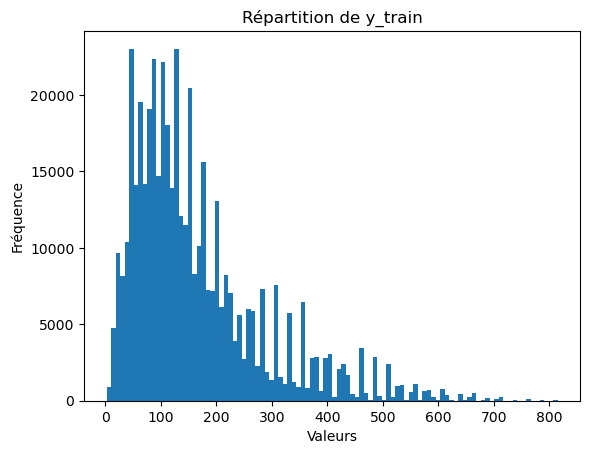

In [163]:

plt.hist(y_train, bins=100)
plt.title("Répartition de y_train")
plt.xlabel("Valeurs")
plt.ylabel("Fréquence")
plt.show()


In [168]:
X_train.columns.tolist()

['Year',
 'CNTRYID',
 'CNTSCHID',
 'CNTSTUID',
 'NatCen',
 'SUBNATIO',
 'OECD',
 'ADMINMODE',
 'LANGTEST_QQQ',
 'LANGTEST_COG',
 'Option_FL',
 'Option_ICTQ',
 'Option_PQ',
 'Option_TQ',
 'Option_UH',
 'ST001D01T',
 'ST003D02T',
 'ST003D03T',
 'ST004D01T',
 'EFFORT1',
 'EFFORT2',
 'OCOD1',
 'OCOD2',
 'OCOD3',
 'AGE',
 'GRADE',
 'IMMIG',
 'COBN_S',
 'WB165',
 'IC171',
 'ST038',
 'ST255',
 'ST034',
 'PA042',
 'IC173',
 'WB154',
 'IC174',
 'ST005',
 'ST021',
 'PA183',
 'ST007',
 'WB163',
 'PA166',
 'ST250',
 'ST296',
 'ST270',
 'ST353',
 'ST349',
 'WB164',
 'ST062',
 'ST254',
 'IC170',
 'reading_q1_average_score',
 'reading_q2_average_score',
 'reading_q3_average_score',
 'reading_q4_average_score',
 'reading_q5_average_score',
 'reading_q6_average_score',
 'math_q1_average_score',
 'math_q2_average_score',
 'math_q3_average_score',
 'math_q4_average_score',
 'math_q5_average_score',
 'math_q6_average_score',
 'math_q7_average_score',
 'math_q8_average_score',
 'math_q9_average_score',
 's

In [93]:
df_zero.describe()

,Year,CNTRYID,CNTSCHID,CNTSTUID,NatCen,SUBNATIO,OECD,ADMINMODE,LANGTEST_QQQ,LANGTEST_COG,...,math_q8_total_timing,math_q9_total_timing,science_q1_total_timing,science_q2_total_timing,science_q3_total_timing,science_q4_total_timing,science_q5_total_timing,science_q6_total_timing,science_q7_total_timing,MathScore
count,311954.000000,311954.000000,311954.000000,311954.000000,311954.000000,311954.000000,311954.000000,311954.000000,311954.000000,311954.000000,...,311954.000000,311954.000000,311954.000000,311954.000000,311954.000000,311954.000000,311954.000000,311954.000000,311954.000000,311954.0
mean,-0.513186,0.021157,0.021159,0.021752,-0.004397,0.011440,0.033890,-0.065395,-0.000820,-0.001246,...,-0.131927,-0.142587,0.009510,0.040052,0.066185,0.041173,0.018743,0.003892,0.031642,0.0
std,0.698508,1.024154,1.024151,1.025015,1.002177,1.011550,1.034393,1.081351,0.995467,0.991580,...,0.110778,0.106734,1.152645,1.176910,1.180000,1.177638,1.165376,1.161671,1.168549,0.0
min,-1.141761,-1.609119,-1.609128,-1.610264,-1.634693,-1.634036,-0.955433,-2.989067,-1.355157,-1.332826,...,-2.059256,-2.023075,-2.188597,-2.234842,-2.171942,-2.131083,-2.249302,-2.450879,-2.400736,0.0
25%,-1.141761,-0.901544,-0.901558,-0.901986,-0.941020,-0.949742,-0.955433,0.334553,-1.062523,-1.045303,...,-0.128947,-0.140899,-0.621072,-0.598255,-0.592354,-0.648517,-0.631690,-0.613007,-0.559478,0.0
50%,-0.090759,-0.085110,-0.085130,-0.084725,-0.085491,-0.063525,0.890554,0.334553,0.005932,0.004492,...,-0.128947,-0.140899,-0.087539,-0.113032,-0.092735,-0.099622,-0.109295,-0.090581,-0.109754,0.0
75%,-0.090759,0.920011,0.919981,0.921368,1.043654,0.968525,0.890554,0.334553,0.883835,0.867062,...,-0.128947,-0.140899,0.420089,0.458145,0.567453,0.502652,0.425323,0.412801,0.404569,0.0
max,1.310579,1.928760,1.928751,1.932149,1.648690,2.011793,2.736540,0.334553,4.667662,4.584808,...,6.751468,7.118403,7.121290,7.103012,7.151369,7.092424,7.077379,7.108206,7.043793,0.0


In [164]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(X_train, y_train)

y_pred = linreg.predict(X_test)


In [165]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("RMSE :", rmse)
print("R² :", r2)


RMSE : 58.49220100299342
R² : 0.7686542431177175


In [166]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1000000.0)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("RMSE :", rmse)
print("R² :", r2)

RMSE : 75.42631419803752
R² : 0.6153095696732815


Meilleur alpha : 0.0001
R² associé : 0.5898706194229975


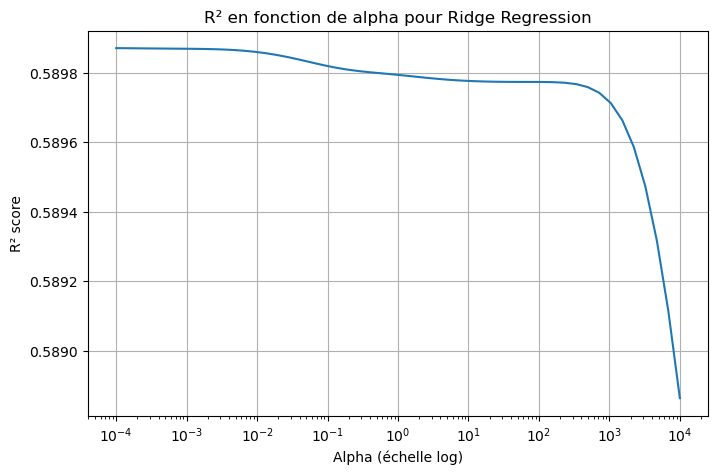

In [85]:
alphas = np.logspace(-4, 4, 50)

r2_scores = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)

# meilleur alpha
best_alpha = alphas[np.argmax(r2_scores)]
best_r2 = max(r2_scores)

print("Meilleur alpha :", best_alpha)
print("R² associé :", best_r2)

# tracé de la courbe
plt.figure(figsize=(8,5))
plt.plot(alphas, r2_scores)
plt.xscale("log")
plt.xlabel("Alpha (échelle log)")
plt.ylabel("R² score")
plt.title("R² en fonction de alpha pour Ridge Regression")
plt.grid(True)
plt.show()